## Distance estimation using Calibrated camera by fused both method


#### Without CNN

In [4]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np

# ===================== USER PARAMETERS =====================
YOLO_MODEL_PATH = r"D:\IITBHU Internship\code\runs\detect\train11\best.pt"

S_min, S_max = 0.4, 0.7   # drone width range (meters)
fx = 550.8                # calibrated focal length (pixels)
s = 680.0                 # calibrated depth scale
CONF_THRESH = 0.4
P_REF = 120               # reference pixel size for geometry confidence

# ===================== LOAD MODELS =====================
yolo = YOLO(YOLO_MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").to(device).eval()
transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

# ===================== CAMERA =====================
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("✅ Fusion-based distance estimation running (press q to quit)")

# ===================== MAIN LOOP =====================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # ---------- YOLO ----------
    yolo_res = yolo(frame, conf=CONF_THRESH, verbose=False)[0]

    # ---------- DEPTH ----------
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_batch = transform(img_rgb).to(device)

    with torch.no_grad():
        depth = midas(input_batch)
        depth = torch.nn.functional.interpolate(
            depth.unsqueeze(1),
            size=frame.shape[:2],
            mode="bicubic",
            align_corners=False
        ).squeeze()

    depth_map = depth.cpu().numpy()

    for box in yolo_res.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        bbox_w = x2 - x1
        bbox_h = y2 - y1
        p = max(bbox_w, bbox_h)
        if p <= 0:
            continue

        # -------- Geometry distance with size range --------
        D_geom_min = (S_min * fx) / p
        D_geom_max = (S_max * fx) / p
        D_geom = (D_geom_min + D_geom_max) / 2  # midpoint estimate

        # -------- Depth distance --------
        roi = depth_map[y1:y2, x1:x2]
        if roi.size == 0:
            continue
        d_raw = np.median(roi)
        D_depth = s / d_raw if d_raw > 0 else 0

        # -------- Confidences --------
        w_geom = min(1.0, p / P_REF)
        depth_std = np.std(roi)
        w_depth = 1.0 / (1.0 + depth_std)

        # Normalize
        w_sum = w_geom + w_depth
        if w_sum == 0:
            continue
        w_geom /= w_sum
        w_depth /= w_sum

        # -------- Fusion --------
        D_fused = w_geom * D_geom + w_depth * D_depth

        # -------- Visualization --------
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f"D={D_fused:.2f}m | G=[{D_geom_min:.2f}-{D_geom_max:.2f}] | Dp={D_depth:.2f}"
        cv2.putText(frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        print(f"Geom=[{D_geom_min:.2f}-{D_geom_max:.2f}] | Depth={D_depth:.2f} | Fused={D_fused:.2f}")

    cv2.imshow("Fusion Distance Estimation", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Using cache found in C:\Users\100ra/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\100ra/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\100ra/.cache\torch\hub\intel-isl_MiDaS_master


✅ Fusion-based distance estimation running (press q to quit)
Geom=[0.35-0.61] | Depth=1.03 | Fused=0.48
Geom=[2.75-4.82] | Depth=1.38 | Fused=3.77
Geom=[2.90-5.07] | Depth=1.37 | Fused=3.97
Geom=[2.94-5.14] | Depth=1.51 | Fused=4.02
Geom=[2.90-5.07] | Depth=1.27 | Fused=3.96
Geom=[2.90-5.07] | Depth=1.38 | Fused=3.96
Geom=[0.47-0.82] | Depth=1.09 | Fused=0.65
Geom=[0.47-0.82] | Depth=1.07 | Fused=0.65
Geom=[0.47-0.83] | Depth=1.14 | Fused=0.65
Geom=[0.49-0.85] | Depth=1.11 | Fused=0.67
Geom=[0.50-0.88] | Depth=1.06 | Fused=0.69
Geom=[0.48-0.85] | Depth=0.97 | Fused=0.67
Geom=[0.41-0.72] | Depth=0.97 | Fused=0.57
Geom=[0.53-0.93] | Depth=1.00 | Fused=0.73
Geom=[0.51-0.90] | Depth=1.02 | Fused=0.71
Geom=[0.35-0.61] | Depth=1.14 | Fused=0.49
Geom=[0.46-0.80] | Depth=1.13 | Fused=0.63
Geom=[0.51-0.88] | Depth=1.23 | Fused=0.70
Geom=[0.50-0.87] | Depth=1.24 | Fused=0.69
Geom=[0.48-0.83] | Depth=1.22 | Fused=0.66
Geom=[0.47-0.82] | Depth=1.10 | Fused=0.65
Geom=[0.50-0.87] | Depth=1.08 | Fuse

#### With yolo+CNN and fused 

In [4]:
from ultralytics import YOLO
import cv2, torch
import numpy as np
from torchvision import models, transforms
from PIL import Image

# ===================== PARAMETERS =====================
YOLO_MODEL_PATH = r"D:\IITBHU Internship\code\runs\detect\train11\best.pt"

S_min, S_max = 0.4, 0.7      # meters
fx = 550.8                  # CALIBRATED focal length (px)
s = 680.0                   # CALIBRATED depth scale
CONF_THRESH = 0.2          # YOLO (LOW for recall)
CNN_THRESH = 0.25           # CNN (practical)
P_REF = 120

# ===================== MODELS =====================
yolo = YOLO(YOLO_MODEL_PATH)

cnn = models.resnet18()
cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
cnn.load_state_dict(torch.load("drone_classifier.pth", map_location="cpu"))
cnn.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)

cnn_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# MiDaS
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").to(device).eval()
midas_transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

# ===================== CAMERA =====================
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("✅ Calibrated Distance Estimation Running (q to quit)")

# ===================== LOOP =====================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    annotated = frame.copy()

    # ---------- YOLO ----------
    res = yolo(frame, conf=CONF_THRESH, verbose=False)[0]

    # ---------- DEPTH ----------
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    inp = midas_transform(img_rgb).to(device)

    with torch.no_grad():
        depth = midas(inp)
        depth = torch.nn.functional.interpolate(
            depth.unsqueeze(1),
            size=frame.shape[:2],
            mode="bicubic",
            align_corners=False
        ).squeeze()

    depth_map = depth.cpu().numpy()

    for box in res.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        # Always draw YOLO box first
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (255,255,0), 1)

        roi = frame[y1:y2, x1:x2]
        if roi.size == 0:
            continue

        # ---------- CNN ----------
        roi_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        roi_tensor = cnn_transform(roi_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            out = cnn(roi_tensor)
            probs = torch.softmax(out, dim=1)[0]
            cls = torch.argmax(probs).item()
            cls_conf = probs[cls].item()

        # ---------- REJECTION VISUAL ----------
        if cls != 0 or cls_conf < CNN_THRESH:
            cv2.putText(
                annotated,
                f"Rejected CNN {cls_conf:.2f}",
                (x1, y1-6),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0,0,255), 2
            )
            continue

        # ---------- DISTANCE ----------
        p = max(x2-x1, y2-y1)
        if p <= 0:
            continue

        D_geom = ((S_min + S_max)/2 * fx) / p

        roi_depth = depth_map[y1:y2, x1:x2]
        D_depth = None
        if roi_depth.size > 0:
            d_raw = np.median(roi_depth)
            if np.isfinite(d_raw) and d_raw > 1e-6:
                D_depth = s / d_raw

        if D_depth is not None:
            w_geom = min(1.0, p/P_REF)
            w_depth = 1.0 / (1.0 + np.std(roi_depth))
            w_sum = w_geom + w_depth
            D_final = (w_geom/w_sum)*D_geom + (w_depth/w_sum)*D_depth
        else:
            D_final = D_geom

        # ---------- VISUAL ----------
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(
            annotated,
            f"Drone | D={D_final:.2f} m",
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6, (0,255,0), 2
        )

    cv2.imshow("Calibrated Drone Distance", annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


C:\Users\100ra\AppData\Local\Temp\ipykernel_15016\2703354583.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn.load_state_dict(torch.load("drone_classifier.pth", map_

Loading weights:  None


Using cache found in C:\Users\100ra/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\100ra/.cache\torch\hub\intel-isl_MiDaS_master


✅ Calibrated Distance Estimation Running (q to quit)


Distance Accuracy Graph


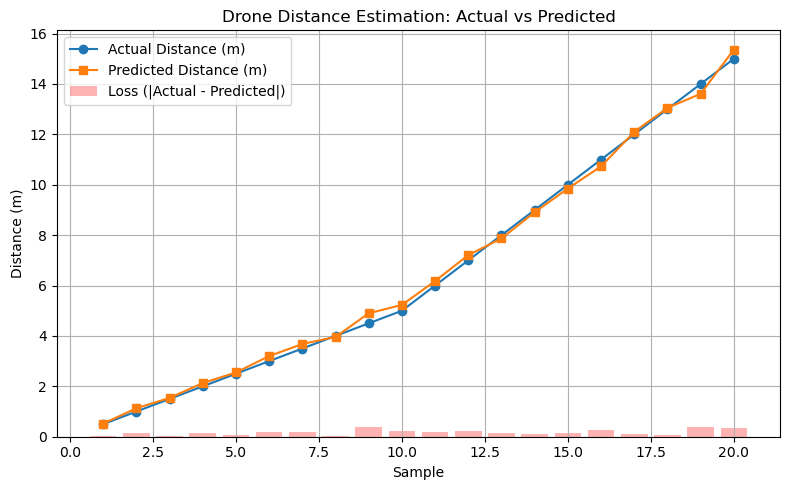

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data
samples = np.arange(1, 21)
actual = np.array([0.50, 1.00, 1.50, 2.00, 2.50, 3.00, 3.50, 4.00, 4.50, 5.00, 6.00, 7.00, 8.00, 9.00, 10.00, 11.00, 12.00, 13.00, 14.00, 15.00])  
predicted = np.array([0.52, 1.13, 1.54, 2.13, 2.55, 3.20, 3.68, 3.96, 4.90, 5.23, 6.18, 7.21, 7.87, 8.91, 9.85, 10.73, 12.10, 13.05, 13.61, 15.36])
loss = np.abs(actual - predicted)

# Plot Actual vs Predicted
plt.figure(figsize=(8,5))
plt.plot(samples, actual, marker='o', label='Actual Distance (m)')
plt.plot(samples, predicted, marker='s', label='Predicted Distance (m)')
plt.bar(samples, loss, alpha=0.3, label='Loss (|Actual - Predicted|)', color='red')

plt.xlabel("Sample")
plt.ylabel("Distance (m)")
plt.title("Drone Distance Estimation: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

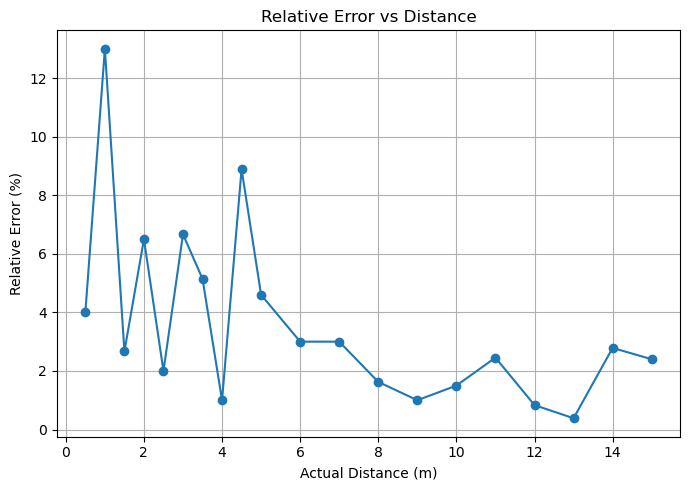

In [9]:
relative_error = np.abs(actual - predicted) / actual * 100

plt.figure(figsize=(7,5))
plt.plot(actual, relative_error, marker='o')
plt.xlabel("Actual Distance (m)")
plt.ylabel("Relative Error (%)")
plt.title("Relative Error vs Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

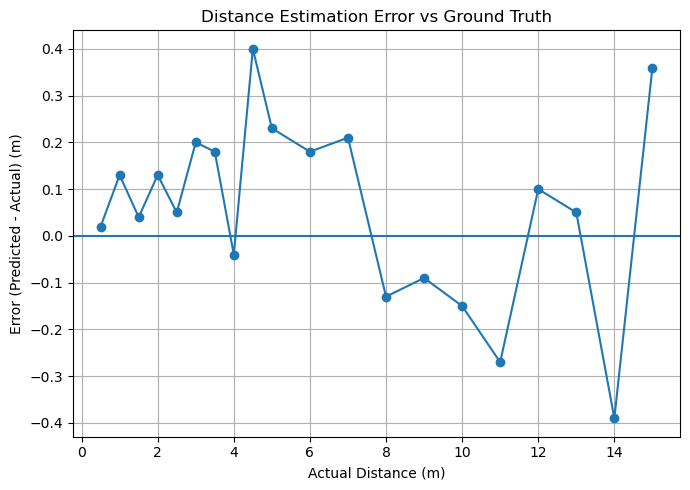

In [10]:
error = predicted - actual

plt.figure(figsize=(7,5))
plt.plot(actual, error, marker='o')
plt.axhline(0)

plt.xlabel("Actual Distance (m)")
plt.ylabel("Error (Predicted - Actual) (m)")
plt.title("Distance Estimation Error vs Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
import numpy as np

# Ground truth and predictions
y_actual = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0])
y_pred   = np.array([0.52, 1.13, 1.54, 2.13, 2.55, 3.20, 3.68, 3.96, 4.90, 5.23, 6.18, 7.21, 7.87])

eps = 1e-6  # numerical stability

# ---------- AbsRel ----------
abs_rel = np.mean(np.abs(y_actual - y_pred) / (y_actual + eps))

# ---------- SqRel ----------
sq_rel = np.mean(((y_actual - y_pred) ** 2) / (y_actual + eps))

# ---------- RMSE (linear) ----------
rmse_lin = np.sqrt(np.mean((y_actual - y_pred) ** 2))

# ---------- RMSE (log) ----------
rmse_log = np.sqrt(
    np.mean((np.log(y_actual + eps) - np.log(y_pred + eps)) ** 2)
)

# ---------- Scale-Invariant RMSE ----------
log_diff = np.log(y_pred + eps) - np.log(y_actual + eps)
alpha = np.mean(log_diff)
srmselog = np.mean((log_diff - alpha) ** 2)

# ---------- Threshold Accuracy ----------
delta = np.maximum(y_actual / (y_pred + eps), y_pred / (y_actual + eps))

acc_1 = np.mean(delta < 1.25)
acc_2 = np.mean(delta < 1.25**2)
acc_3 = np.mean(delta < 1.25**3)

# ---------- Print ----------
print(f"AbsRel     : {abs_rel:.4f}")
print(f"SqRel      : {sq_rel:.4f}")
print(f"RMSE (lin) : {rmse_lin:.4f} m")
print(f"RMSE (log) : {rmse_log:.4f}")
print(f"sRMSE (log): {srmselog:.4f}")
print(f"δ < 1.25   : {acc_1*100:.2f}%")
print(f"δ < 1.25²  : {acc_2*100:.2f}%")
print(f"δ < 1.25³  : {acc_3*100:.2f}%")


AbsRel     : 0.0478
SqRel      : 0.0086
RMSE (lin) : 0.1794 m
RMSE (log) : 0.0552
sRMSE (log): 0.0013
δ < 1.25   : 100.00%
δ < 1.25²  : 100.00%
δ < 1.25³  : 100.00%


# Speed

In [7]:
import cv2
import math
import numpy as np
import torch
import time
from ultralytics import YOLO
from torchvision import models, transforms
from PIL import Image

# ===================== PARAMETERS =====================
YOLO_MODEL_PATH = r"D:\IITBHU Internship\code\runs\detect\train11\best.pt"
CNN_MODEL_PATH  = "drone_classifier.pth"

S_MIN_M, S_MAX_M = 0.4, 0.7        # Drone size range (meters)
fx = 550.8                         # Calibrated focal length (pixels)
DEPTH_SCALE = 680.0                # Depth calibration scale
P_REF = 200                        # Reference pixel size for weighting

CONF_THRESH = 0.15
CNN_THRESH  = 0.35

# ===================== MODELS =====================
yolo = YOLO(YOLO_MODEL_PATH)

cnn = models.resnet18()
cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
cnn.load_state_dict(torch.load(CNN_MODEL_PATH, map_location="cpu"))
cnn.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# ===================== MiDaS DEPTH =====================
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").to(device).eval()
midas_transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

# ===================== CAMERA =====================
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

prev_state = {}   # id -> (cx, cy, D, t)

print("Drone Distance + Speed Estimation Running (Press q to quit)")

# ===================== MAIN LOOP =====================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    t_now = time.time()
    annotated = frame.copy()

    # ---------- YOLO ----------
    results = yolo(frame, conf=CONF_THRESH, verbose=False)[0]

    # ---------- DEPTH ----------
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    inp = midas_transform(rgb).to(device)

    with torch.no_grad():
        depth_pred = midas(inp)
        depth_pred = torch.nn.functional.interpolate(
            depth_pred.unsqueeze(1),
            size=rgb.shape[:2],
            mode="bicubic",
            align_corners=False
        ).squeeze().cpu().numpy()

    # ---------- PER DETECTION ----------
    for i, box in enumerate(results.boxes):

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        p = max(1, max(x2 - x1, y2 - y1))

        cv2.rectangle(annotated, (x1,y1), (x2,y2), (255,255,0), 1)

        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        # ---------- CNN VERIFICATION ----------
        crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        inp_cnn = transform(crop_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            out = cnn(inp_cnn)
            probs = torch.softmax(out, dim=1)[0].cpu().numpy()
            cls = np.argmax(probs)
            cls_conf = probs[cls]

        if cls != 0 or cls_conf < CNN_THRESH:
            cv2.putText(
                annotated,
                f"Rejected {cls_conf:.2f}",
                (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0,0,255), 2
            )
            continue

        # ---------- GEOMETRIC DISTANCE ----------
        S_avg = 0.5 * (S_MIN_M + S_MAX_M)
        D_geom = (S_avg * fx) / p

        # ---------- DEPTH DISTANCE ----------
        roi_depth = depth_pred[y1:y2, x1:x2]
        D_depth = None

        if roi_depth.size > 0:
            d_raw = np.median(roi_depth)
            if np.isfinite(d_raw) and d_raw > 1e-6:
                D_depth = DEPTH_SCALE / d_raw

        # ---------- FUSION ----------
        if D_depth is not None:
            w_geom  = min(1.0, p / P_REF)
            w_depth = 1.0 / (1.0 + np.std(roi_depth))
            w_sum   = w_geom + w_depth
            D_final = (w_geom/w_sum)*D_geom + (w_depth/w_sum)*D_depth
        else:
            D_final = D_geom

        # ---------- SPEED ----------
        cx = 0.5 * (x1 + x2)
        cy = 0.5 * (y1 + y2)
        speed = None

        if i in prev_state:
            px, py, pD, pt = prev_state[i]
            dt = t_now - pt
            if dt > 0.02 and pD is not None:
                v_rad = (D_final - pD) / dt
                dpix  = math.hypot(cx - px, cy - py)
                v_lat = (pD * dpix) / (fx * dt)
                speed = math.sqrt(v_rad**2 + v_lat**2)

        prev_state[i] = (cx, cy, D_final, t_now)

        # ---------- VISUAL ----------
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,255,0), 2)

        cv2.putText(
            annotated,
            f"D: {D_final:.1f} m",
            (x1+5, y1+18),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5, (0,255,0), 2
        )

        if speed is not None:
            cv2.putText(
                annotated,
                f"V: {speed:.1f} m/s",
                (x1+5, y1+36),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255,255,0), 2
            )

    cv2.imshow("Drone Distance + Speed", annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

C:\Users\100ra\AppData\Local\Temp\ipykernel_15016\677608414.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=

Loading weights:  None


Using cache found in C:\Users\100ra/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\100ra/.cache\torch\hub\intel-isl_MiDaS_master


Drone Distance + Speed Estimation Running (Press q to quit)


## Getting time stamp : (Distance + speed)

In [39]:
import cv2, torch, time, math
import numpy as np
from ultralytics import YOLO
from torchvision import models, transforms
from PIL import Image

# ===================== USER PARAMETERS =====================
YOLO_MODEL_PATH = r"D:\IITBHU Internship\code\runs\detect\train11\best.pt"
CNN_MODEL_PATH  = r"D:\IITBHU Internship\code\drone_classifier.pth"

S_min, S_max = 0.4, 0.7
fx = 550.8
s = 680.0
CONF_THRESH = 0.2
CNN_THRESH = 0.35
P_REF = 120

# ===================== LOAD MODELS =====================
yolo = YOLO(YOLO_MODEL_PATH)

cnn = models.resnet18(pretrained=False)
cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
cnn.load_state_dict(torch.load(CNN_MODEL_PATH, map_location="cpu"))
cnn.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)

cnn_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").to(device).eval()
midas_transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

# ===================== CAMERA =====================
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("✅ Full system running (YOLO + CNN + Distance + Speed + Timing)")
print("Press 'q' to quit")

# ===================== MEMORY =====================
prev_state = {}   # id -> (cx, cy, D, t)

# ===================== TIMING =====================
frame_count = 0
global_start = time.time()

# ===================== MAIN LOOP =====================
while True:
    loop_start = time.time()
    ret, frame = cap.read()
    if not ret:
        break

    t_now = time.time()
    annotated = frame.copy()

    # ---------- YOLO ----------
    t0 = time.time()
    yolo_res = yolo(frame, conf=CONF_THRESH, verbose=False)[0]
    t1 = time.time()

    # ---------- DEPTH ----------
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_batch = midas_transform(img_rgb).to(device)

    with torch.no_grad():
        depth = midas(input_batch)
        depth = torch.nn.functional.interpolate(
            depth.unsqueeze(1),
            size=frame.shape[:2],
            mode="bicubic",
            align_corners=False
        ).squeeze()

    depth_map = depth.cpu().numpy()
    t2 = time.time()

    cnn_time = 0.0
    cnn_count = 0

    # ---------- OBJECT LOOP ----------
    for i, box in enumerate(yolo_res.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Always show YOLO box
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (255,255,0), 1)

        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        roi_tensor = cnn_transform(crop_pil).unsqueeze(0).to(device)

        # ---------- CNN ----------
        t3 = time.time()
        with torch.no_grad():
            pred = cnn(roi_tensor)
            probs = torch.softmax(pred, dim=1)[0]
            cls = torch.argmax(probs).item()
            cls_conf = probs[cls].item()
        t4 = time.time()

        cnn_time += (t4 - t3)
        cnn_count += 1

        # ---------- CNN REJECTION (VISIBLE) ----------
        if cls != 0 or cls_conf < CNN_THRESH:
            cv2.putText(
                annotated,
                f"Rejected CNN {cls_conf:.2f}",
                (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0,0,255), 2
            )
            continue

        # ---------- DISTANCE ----------
        p = max(x2 - x1, y2 - y1)
        if p <= 0:
            continue

        D_geom = ((S_min + S_max) / 2 * fx) / p

        roi_depth = depth_map[y1:y2, x1:x2]
        D_depth = None
        if roi_depth.size > 0:
            d_raw = np.median(roi_depth)
            if np.isfinite(d_raw) and d_raw > 1e-6:
                D_depth = s / d_raw

        if D_depth is not None:
            w_geom = min(1.0, p / P_REF)
            w_depth = 1.0 / (1.0 + np.std(roi_depth))
            w_sum = w_geom + w_depth
            D_final = (w_geom/w_sum) * D_geom + (w_depth/w_sum) * D_depth
        else:
            D_final = D_geom

        # ---------- SPEED ----------
        cx, cy = 0.5*(x1+x2), 0.5*(y1+y2)
        speed = None

        if i in prev_state:
            px, py, pD, pt = prev_state[i]
            dt = t_now - pt
            if dt > 0.02 and pD is not None:
                v_rad = (D_final - pD) / dt
                dpix = math.hypot(cx - px, cy - py)
                v_lat = (pD * dpix) / (fx * dt)
                speed = math.sqrt(v_rad**2 + v_lat**2)

        prev_state[i] = (cx, cy, D_final, t_now)

        # ---------- VISUAL ----------
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(annotated, f"D: {D_final:.1f} m",
                    (x1+5, y1+18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
        if speed is not None:
            cv2.putText(annotated, f"V: {speed:.1f} m/s",
                        (x1+5, y1+36),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 2)

    # ---------- FRAME TIMING ----------
    loop_end = time.time()
    frame_time = loop_end - loop_start
    fps = 1.0 / frame_time if frame_time > 0 else 0
    avg_cnn_time = (cnn_time / cnn_count) if cnn_count > 0 else 0.0

    print(
        f"FPS: {fps:.2f} | "
        f"YOLO: {(t1-t0)*1000:.1f} ms | "
        f"Depth: {(t2-t1)*1000:.1f} ms | "
        f"CNN(avg): {avg_cnn_time*1000:.1f} ms | "
        f"Total: {frame_time*1000:.1f} ms"
    )

    frame_count += 1
    cv2.imshow("Drone Distance + Speed + Timing", annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ===================== FINAL STATS =====================
total_time = time.time() - global_start
print("\n===== FINAL PERFORMANCE =====")
print(f"Total runtime: {total_time:.2f} s")
print(f"Total frames: {frame_count}")
print(f"Average FPS: {frame_count / total_time:.2f}")

cap.release()
cv2.destroyAllWindows()


C:\Users\100ra\AppData\Local\Temp\ipykernel_2000\2157597392.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=

Loading weights:  None


Using cache found in C:\Users\100ra/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\100ra/.cache\torch\hub\intel-isl_MiDaS_master


✅ Full system running (YOLO + CNN + Distance + Speed + Timing)
Press 'q' to quit
FPS: 1.32 | YOLO: 219.3 ms | Depth: 54.0 ms | CNN(avg): 12.8 ms | Total: 756.2 ms
FPS: 7.73 | YOLO: 41.6 ms | Depth: 57.9 ms | CNN(avg): 13.3 ms | Total: 129.4 ms
FPS: 7.51 | YOLO: 46.4 ms | Depth: 60.6 ms | CNN(avg): 15.5 ms | Total: 133.1 ms
FPS: 8.37 | YOLO: 41.6 ms | Depth: 53.3 ms | CNN(avg): 13.5 ms | Total: 119.4 ms
FPS: 8.07 | YOLO: 39.4 ms | Depth: 57.4 ms | CNN(avg): 13.3 ms | Total: 123.9 ms
FPS: 7.92 | YOLO: 43.0 ms | Depth: 58.7 ms | CNN(avg): 13.5 ms | Total: 126.3 ms
FPS: 8.74 | YOLO: 35.5 ms | Depth: 54.3 ms | CNN(avg): 13.1 ms | Total: 114.4 ms
FPS: 8.23 | YOLO: 39.6 ms | Depth: 59.2 ms | CNN(avg): 12.4 ms | Total: 121.6 ms
FPS: 7.13 | YOLO: 44.0 ms | Depth: 68.3 ms | CNN(avg): 14.3 ms | Total: 140.3 ms
FPS: 8.97 | YOLO: 39.8 ms | Depth: 49.4 ms | CNN(avg): 11.6 ms | Total: 111.5 ms
FPS: 8.10 | YOLO: 36.9 ms | Depth: 58.0 ms | CNN(avg): 13.3 ms | Total: 123.4 ms
FPS: 8.18 | YOLO: 38.4 ms |

# Without Calibrated

# Distance

In [25]:
import cv2, math, numpy as np, torch
from ultralytics import YOLO
from torchvision import models, transforms
from PIL import Image

# ---------- Config ----------
S_MIN_M, S_MAX_M = 0.25, 0.80  # drone width range (m), tune per target class
HFOV_DEG = 60.0                # camera HFOV (deg) or calibrate f directly
CNN_THRESH = 0.2               # accept if CNN says 'drone' above this
DEPTH_SCALE_S = 20.0           # set via calibration: s = Z_known * d_raw_known

# ---------- Focal from FOV ----------
def focal_from_fov(width_px, hfov_deg):
    return width_px / (2.0 * math.tan(math.radians(hfov_deg / 2.0)))

# ---------- Geometry helpers ----------
def interval_from_bbox(w_px, f_x, smin, smax):
    if w_px <= 0: return None
    dmin = (smin * f_x) / w_px
    dmax = (smax * f_x) / w_px
    return (min(dmin, dmax), max(dmin, dmax))

def fuse_intervals(iv_a, iv_b):
    if iv_a is None and iv_b is None: return None
    if iv_a is None: return iv_b
    if iv_b is None: return iv_a
    lo = max(iv_a[0], iv_b[0]); hi = min(iv_a[1], iv_b[1])
    if lo > hi:
        m = ((iv_a[0]+iv_a[1]) + (iv_b[0]+iv_b[1])) / 4.0
        return (m, m)
    return (lo, hi)

# ---------- Depth (MiDaS small) ----------
import torch
import cv2
import numpy as np

class MidasDepth:
    def __init__(self, device="cpu"):
        self.device = torch.device(device)
        # Use MiDaS_small (fast) or DPT_Hybrid (better quality)
        self.model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
        self.model.to(self.device).eval()
        # Load transforms
        midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        self.transform = midas_transforms.small_transform

    def infer(self, bgr):
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        inp = self.transform(rgb).to(self.device)
        with torch.no_grad():
            pred = self.model(inp)
            pred = torch.nn.functional.interpolate(
                pred.unsqueeze(1),
                size=rgb.shape[:2],
                mode="bicubic",
                align_corners=False
            ).squeeze().cpu().numpy()
        return pred  # depth map (relative/inverse depth)

# ---------- Models ----------
yolo = YOLO(r"D:\IITBHU Internship\code\runs\detect\train11\best.pt")

cnn = models.resnet18()
cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
cnn.load_state_dict(torch.load("drone_classifier.pth", map_location="cpu"))
cnn.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
classes = ["drone","non_drone"]

depth_net = MidasDepth(device=str(device))

# ---------- Camera ----------
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Webcam not opening"); raise SystemExit
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 1280
f_x = focal_from_fov(W, HFOV_DEG)

# ---------- Loop ----------
while True:
    ok, frame = cap.read()
    if not ok: break
    H, W = frame.shape[:2]
    res = yolo(frame, conf=0.25, device=0, verbose=False)[0]
    depth_map = depth_net.infer(frame)
    annotated = frame.copy()

    for box in res.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        w_px = max(1, max(x2 - x1, y2 - y1))

        # CNN confirmation
        crop = frame[max(0,y1):min(H,y2), max(0,x1):min(W,x2)]
        if crop.size == 0: continue
        crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        inp = transform(crop_pil).unsqueeze(0).to(device)
        with torch.no_grad():
            out = cnn(inp)
            probs = torch.softmax(out, dim=1).cpu().numpy()[0]
            pred = int(np.argmax(probs))
        if classes[pred] != "drone" or probs[pred] < CNN_THRESH:
            cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,0,255), 1)
            cv2.putText(annotated, f"Rejected {probs[pred]:.2f}", (x1, y1-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 1)
            continue

        # Geometry interval (RGB)
        iv_rgb = interval_from_bbox(w_px, f_x, S_MIN_M, S_MAX_M)

        # Depth estimate from bbox median (inverse-depth scale)
        roi = depth_map[max(0,y1):min(H,y2), max(0,x1):min(W,x2)]
        D_depth = None
        if roi.size > 0:
            d_raw = float(np.median(roi))
            D_depth = DEPTH_SCALE_S / max(d_raw, 1e-6)


        # Intersect geometry + (optional other geometry/IR)
        iv_fused = iv_rgb
        D_geom_mid = None
        if iv_fused is not None:
            D_geom_mid = 0.5 * (iv_fused[0] + iv_fused[1])

        # Final fusion
        if D_geom_mid is not None and D_depth is not None:
            D_final = (0.6 * D_geom_mid + 0.4 * D_depth) / (0.6 + 0.4)
            shown = f"[{iv_fused[0]:.1f}-{iv_fused[1]:.1f}] | depth {D_depth:.1f} | D {D_final:.1f} m"
        elif D_geom_mid is not None:
            D_final = D_geom_mid
            shown = f"[{iv_fused[0]:.1f}-{iv_fused[1]:.1f}] | D {D_final:.1f} m"
        elif D_depth is not None:
            D_final = D_depth
            shown = f"depth {D_final:.1f} m"
        else:
            D_final = None
            shown = "D=?"

        # Draw
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,200,0), 2)
        cv2.putText(annotated, shown, (x1, max(0,y1-10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,200,0), 2)
        



        

    cv2.imshow("Multimodel + Distance (Interval ∩ Depth)", annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()

C:\Users\100ra\AppData\Local\Temp\ipykernel_2000\2540400424.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn.load_state_dict(torch.load("drone_classifier.pth", map_l

Loading weights:  None


Using cache found in C:\Users\100ra/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\100ra/.cache\torch\hub\intel-isl_MiDaS_master


## Distance + Speed

In [ ]:
import cv2, math, numpy as np, torch, time
from ultralytics import YOLO
from torchvision import models, transforms
from PIL import Image

# ---------- Config ----------
S_MIN_M, S_MAX_M = 0.25, 0.80
HFOV_DEG = 60.0
CNN_THRESH = 0.6
DEPTH_SCALE_S = 20.0

# ---------- Focal from FOV ----------
def focal_from_fov(width_px, hfov_deg):
    return width_px / (2.0 * math.tan(math.radians(hfov_deg / 2.0)))

# ---------- Geometry ----------
def interval_from_bbox(w_px, f_x, smin, smax):
    if w_px <= 0: return None
    dmin = (smin * f_x) / w_px
    dmax = (smax * f_x) / w_px
    return (min(dmin, dmax), max(dmin, dmax))

def fuse_intervals(iv_a, iv_b):
    if iv_a is None and iv_b is None: return None
    if iv_a is None: return iv_b
    if iv_b is None: return iv_a
    lo = max(iv_a[0], iv_b[0]); hi = min(iv_a[1], iv_b[1])
    if lo > hi:
        m = ((iv_a[0]+iv_a[1]) + (iv_b[0]+iv_b[1])) / 4.0
        return (m, m)
    return (lo, hi)

# ---------- MiDaS Depth ----------
class MidasDepth:
    def __init__(self, device="cpu"):
        self.device = torch.device(device)
        self.model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
        self.model.to(self.device).eval()
        midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        self.transform = midas_transforms.small_transform

    def infer(self, bgr):
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        inp = self.transform(rgb).to(self.device)
        with torch.no_grad():
            pred = self.model(inp)
            pred = torch.nn.functional.interpolate(
                pred.unsqueeze(1),
                size=rgb.shape[:2],
                mode="bicubic",
                align_corners=False
            ).squeeze().cpu().numpy()
        return pred  # depth map

# ---------- Models ----------
yolo = YOLO(r"D:\IITBHU Internship\code\runs\detect\train8\weights\best.pt")

cnn = models.resnet18()
cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
cnn.load_state_dict(torch.load("drone_classifier.pth", map_location="cpu"))
cnn.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
classes = ["drone","non_drone"]

depth_net = MidasDepth(device=str(device))

# ---------- Camera ----------
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Camera error"); exit()

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 1280
f_x = focal_from_fov(W, HFOV_DEG)

# ---------- Speed memory ----------
prev_state = {}  # id -> (cx, cy, D, t)

# ---------- Main Loop ----------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    t_now = time.time()
    H, W = frame.shape[:2]
    annotated = frame.copy()

    res = yolo(frame, conf=0.25, device=0, verbose=False)[0]
    depth_map = depth_net.infer(frame)

    for i, box in enumerate(res.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        w_px = max(1, max(x2 - x1, y2 - y1))

        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        inp = transform(crop_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            out = cnn(inp)
            probs = torch.softmax(out, dim=1).cpu().numpy()[0]
            pred = np.argmax(probs)


        if classes[pred] != "drone" or probs[pred] < CNN_THRESH:
            continue

        # ---------- Distance ----------
        iv = interval_from_bbox(w_px, f_x, S_MIN_M, S_MAX_M)
        roi = depth_map[y1:y2, x1:x2]
        D_depth = None

        if roi.size > 0:
            d_raw = np.median(roi)
            if np.isfinite(d_raw) and d_raw > 1e-6:
                D_depth = DEPTH_SCALE_S / d_raw

        D_final = None
        if iv is not None:
            D_geom = 0.5 * (iv[0] + iv[1])
            D_final = 0.6 * D_geom + 0.4 * D_depth if D_depth else D_geom
        elif D_depth:
            D_final = D_depth

        # ---------- Speed ----------
        cx = 0.5 * (x1 + x2)
        cy = 0.5 * (y1 + y2)
        speed = None

        if i in prev_state and D_final is not None and np.isfinite(D_final):
            px, py, pD, pt = prev_state[i]
            if pD is not None and np.isfinite(pD):
                dt = t_now - pt
                if dt > 0.02:  # avoid tiny dt spikes
                    v_rad = (D_final - pD) / dt
                    dpix = math.hypot(cx - px, cy - py)
                    v_lat = (pD * dpix) / (f_x * dt)
                    if np.isfinite(v_rad) and np.isfinite(v_lat):
                        speed = math.sqrt(v_rad**2 + v_lat**2)

        prev_state[i] = (cx, cy, D_final, t_now)

        # ---------- Draw Box + Text ----------
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
        ty = y1 + 18

        if D_final is not None and np.isfinite(D_final):
            cv2.putText(annotated, f"D: {D_final:.1f} m",
                        (x1+5, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (0,255,0), 2)
            ty += 18

        if speed is not None and np.isfinite(speed):
            cv2.putText(annotated, f"V: {speed:.1f} m/s",
                        (x1+5, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (255,255,0), 2)

    cv2.imshow("Drone Distance + Speed", annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

C:\Users\100ra\AppData\Local\Temp\ipykernel_10876\2891590148.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn.load_state_dict(torch.load("drone_classifier.pth", map_

Loading weights:  None


Using cache found in C:\Users\100ra/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\100ra/.cache\torch\hub\intel-isl_MiDaS_master


drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
drone
dron

## frame Index correction code

In [3]:
import cv2, math, numpy as np, torch, time, os
import psutil
from ultralytics import YOLO
from torchvision import models, transforms
from PIL import Image

# ==========================================
# 1. IEEE Performance Profiler
# ==========================================
class PerformanceProfiler:
    def __init__(self):
        self.times = []
        self.cpu_ram = []
        self.gpu_vram = []
        
    def start(self):
        self.t0 = time.time()
        
    def stop(self):
        t1 = time.time()
        self.times.append(t1 - self.t0)
        process = psutil.Process(os.getpid())
        self.cpu_ram.append(process.memory_info().rss / (1024 * 1024))
        if torch.cuda.is_available():
            self.gpu_vram.append(torch.cuda.memory_allocated() / (1024 * 1024))
            
    def print_report(self):
        valid_times = self.times[5:] if len(self.times) > 10 else self.times
        valid_ram = self.cpu_ram[5:] if len(self.cpu_ram) > 10 else self.cpu_ram
        valid_vram = self.gpu_vram[5:] if len(self.gpu_vram) > 10 else self.gpu_vram

        avg_time = sum(valid_times) / len(valid_times) if valid_times else 0
        fps = 1.0 / avg_time if avg_time > 0 else 0
        avg_ram = sum(valid_ram) / len(valid_ram) if valid_ram else 0
        avg_vram = sum(valid_vram) / len(valid_vram) if valid_vram else 0
        
        print("\n" + "="*45)
        print("   IEEE PERFORMANCE BENCHMARK REPORT   ")
        print("="*45)
        print(f"Average FPS:        {fps:.2f} frames/sec")
        print(f"Inference Latency:  {avg_time*1000:.2f} ms")
        print(f"Avg CPU RAM Usage:  {avg_ram:.2f} MB")
        if torch.cuda.is_available():
            print(f"Avg GPU VRAM Usage: {avg_vram:.2f} MB")
        print("="*45 + "\n")

# ==========================================
# 2. Configuration & Helpers
# ==========================================
S_MIN_M, S_MAX_M = 0.25, 0.80  # Drone size interval in meters
HFOV_DEG = 60.0                # Camera Horizontal Field of View
CNN_THRESH = 0.6               # ResNet Verification Threshold
DEPTH_SCALE_S = 20.0           # MiDaS Depth Scaling Factor
P_REF = 150.0                  # Reference pixel size for geometric confidence (Paper Eq)

def focal_from_fov(width_px, hfov_deg):
    return width_px / (2.0 * math.tan(math.radians(hfov_deg / 2.0)))

def interval_from_bbox(w_px, f_x, smin, smax):
    if w_px <= 0: return None
    dmin = (smin * f_x) / w_px
    dmax = (smax * f_x) / w_px
    return (min(dmin, dmax), max(dmin, dmax))

# ==========================================
# 3. MiDaS Depth Class
# ==========================================
class MidasDepth:
    def __init__(self, device="cpu"):
        self.device = torch.device(device)
        self.model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
        self.model.to(self.device).eval()
        midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        self.transform = midas_transforms.small_transform

    def infer(self, bgr):
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        inp = self.transform(rgb).to(self.device)
        with torch.no_grad():
            pred = self.model(inp)
            pred = torch.nn.functional.interpolate(
                pred.unsqueeze(1),
                size=rgb.shape[:2],
                mode="bicubic",
                align_corners=False
            ).squeeze().cpu().numpy()
        return pred  

# ==========================================
# 4. Model Initialization
# ==========================================
print("Loading Models...")
yolo = YOLO(r"D:\IITBHU Internship\code\runs\detect\train8\weights\best.pt")

cnn = models.resnet18()
cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
cnn.load_state_dict(torch.load("drone_classifier.pth", map_location="cpu"))
cnn.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
classes = ["drone", "non_drone"] 

depth_net = MidasDepth(device=str(device))
profiler = PerformanceProfiler()

# ==========================================
# 5. Video Capture & Main Loop
# ==========================================
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Camera error"); exit()

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 1280
f_x = focal_from_fov(W, HFOV_DEG)

prev_state = {}  # Tracking memory: id -> (cx, cy, D, t)

print("Starting Inference... Press 'q' to stop and generate report.")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # START HARDWARE TRACKING
    profiler.start()
    
    t_now = time.time()
    H, W = frame.shape[:2]
    annotated = frame.copy()

    # Model Inference
    res = yolo(frame, conf=0.25, device=0, verbose=False)[0]
    depth_map = depth_net.infer(frame)

    claimed_ids = set() # Track IDs claimed in this specific frame

    for box in res.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        w_px = max(1, max(x2 - x1, y2 - y1))

        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        inp = transform(crop_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            out = cnn(inp)
            probs = torch.softmax(out, dim=1).cpu().numpy()[0]
            pred = np.argmax(probs)

        # ResNet Rejection Logic
        if classes[pred] != "drone" or probs[pred] < CNN_THRESH:
            continue

        # --- Dynamic Confidence-Aware Distance Computation (Paper Sec III.C) ---
        iv = interval_from_bbox(w_px, f_x, S_MIN_M, S_MAX_M)
        roi = depth_map[y1:y2, x1:x2]
        
        D_depth = None
        sigma_d = 0.0

        if roi.size > 0:
            d_raw = np.median(roi)
            sigma_d = np.std(roi) # Depth standard deviation for fusion weight
            if np.isfinite(d_raw) and d_raw > 1e-6:
                D_depth = DEPTH_SCALE_S / d_raw

        D_final = None
        if iv is not None:
            D_geom = 0.5 * (iv[0] + iv[1])
            
            if D_depth is not None:
                # 1. Calculate unnormalized weights based on paper formulas
                w_geom = min(w_px / P_REF, 1.0)
                w_depth = 1.0 / (1.0 + sigma_d)
                
                # 2. Normalize the weights
                w_total = w_geom + w_depth
                w_geom_hat = w_geom / w_total      
                w_depth_hat = w_depth / w_total    
                
                # 3. Final fused distance
                D_final = (w_geom_hat * D_geom) + (w_depth_hat * D_depth)
            else:
                D_final = D_geom
        elif D_depth:
            D_final = D_depth

        # --- Robust Speed Tracking (Paper Sec III.D) ---
        cx = 0.5 * (x1 + x2)
        cy = 0.5 * (y1 + y2)
        speed = None
        
        # 1. Match with closest drone from previous frame (Euclidean Distance)
        best_id = -1
        min_dist = float('inf')
        for track_id, (px, py, pD, pt) in prev_state.items():
            if track_id in claimed_ids:
                continue
            
            dist = math.hypot(cx - px, cy - py)
            if dist < 150 and dist < min_dist: 
                min_dist = dist
                best_id = track_id

        # 2. Assign new ID if lost/new
        if best_id == -1:
            best_id = len(prev_state) if len(prev_state) == 0 else max(prev_state.keys()) + 1

        claimed_ids.add(best_id)

        # 3. Calculate Speed safely
        if best_id in prev_state and D_final is not None and np.isfinite(D_final):
            px, py, pD, pt = prev_state[best_id]
            if pD is not None and np.isfinite(pD):
                dt = t_now - pt
                if dt > 0.02:  
                    v_rad = (D_final - pD) / dt
                    dpix = math.hypot(cx - px, cy - py)
                    v_lat = (pD * dpix) / (f_x * dt)
                    if np.isfinite(v_rad) and np.isfinite(v_lat):
                        speed = math.sqrt(v_rad**2 + v_lat**2)

        # 4. Update state memory
        prev_state[best_id] = (cx, cy, D_final, t_now)

        # --- Draw Annotations ---
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
        ty = y1 + 18

        if D_final is not None and np.isfinite(D_final):
            cv2.putText(annotated, f"D: {D_final:.1f} m", (x1+5, ty), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
            ty += 18

        if speed is not None and np.isfinite(speed):
            cv2.putText(annotated, f"V: {speed:.1f} m/s", (x1+5, ty), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 2)

    # STOP HARDWARE TRACKING
    profiler.stop()

    cv2.imshow("Drone Distance + Speed Benchmark", annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Clean up and print the paper metrics
cap.release()
cv2.destroyAllWindows()
profiler.print_report()

Loading Models...


C:\Users\100ra\AppData\Local\Temp\ipykernel_10876\3611755654.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn.load_state_dict(torch.load("drone_classifier.pth", map_

Loading weights:  None


HTTPError: HTTP Error 504: Gateway Time-out

## Test on video


In [2]:
import cv2, math, numpy as np, torch, time
from ultralytics import YOLO
from torchvision import models, transforms
from PIL import Image

# ---------- Config ----------
S_MIN_M, S_MAX_M = 0.25, 0.80
HFOV_DEG = 60.0
CNN_THRESH = 0.6
DEPTH_SCALE_S = 20.0

# ---------- Focal from FOV ----------
def focal_from_fov(width_px, hfov_deg):
    return width_px / (2.0 * math.tan(math.radians(hfov_deg / 2.0)))

# ---------- Geometry ----------
def interval_from_bbox(w_px, f_x, smin, smax):
    if w_px <= 0: return None
    dmin = (smin * f_x) / w_px
    dmax = (smax * f_x) / w_px
    return (min(dmin, dmax), max(dmin, dmax))

def fuse_intervals(iv_a, iv_b):
    if iv_a is None and iv_b is None: return None
    if iv_a is None: return iv_b
    if iv_b is None: return iv_a
    lo = max(iv_a[0], iv_b[0]); hi = min(iv_a[1], iv_b[1])
    if lo > hi:
        m = ((iv_a[0]+iv_a[1]) + (iv_b[0]+iv_b[1])) / 4.0
        return (m, m)
    return (lo, hi)

# ---------- MiDaS Depth ----------
class MidasDepth:
    def __init__(self, device="cpu"):
        self.device = torch.device(device)
        self.model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
        self.model.to(self.device).eval()
        midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        self.transform = midas_transforms.small_transform

    def infer(self, bgr):
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        inp = self.transform(rgb).to(self.device)
        with torch.no_grad():
            pred = self.model(inp)
            pred = torch.nn.functional.interpolate(
                pred.unsqueeze(1),
                size=rgb.shape[:2],
                mode="bicubic",
                align_corners=False
            ).squeeze().cpu().numpy()
        return pred  # depth map

# ---------- Models ----------
yolo = YOLO(r"D:\IITBHU Internship\code\runs\detect\train8\weights\best.pt")

cnn = models.resnet18()
cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
cnn.load_state_dict(torch.load("drone_classifier.pth", map_location="cpu"))
cnn.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
classes = ["drone","non_drone"]

depth_net = MidasDepth(device=str(device))

# ---------- Video ----------
# ===============================================
# Replace 'drone_video.mp4' with the path to your test video
video_path = r"C:\Users\100ra\Downloads\20251215_121854.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Video not opening")
    raise SystemExit

# Get video properties
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) 
fps = cap.get(cv2.CAP_PROP_FPS)



print(f"Video resolution: {W}x{H}, FPS: {fps}")

# Example: focal length calculation (assuming you have focal_from_fov defined)
HFOV_DEG = 90  # example horizontal field of view
f_x = focal_from_fov(W, HFOV_DEG)

# ==================================================================


# ---------- Speed memory ----------
prev_state = {}  # id -> (cx, cy, D, t)

# ---------- Main Loop ----------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    t_now = time.time()
    H, W = frame.shape[:2]
    annotated = frame.copy()

    cv2.putText(annotated, f"Resolution: {W}x{H}", (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

    res = yolo(frame, conf=0.25, device=0, verbose=False)[0]
    depth_map = depth_net.infer(frame)

    for i, box in enumerate(res.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        w_px = max(1, max(x2 - x1, y2 - y1))

        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        inp = transform(crop_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            out = cnn(inp)
            probs = torch.softmax(out, dim=1).cpu().numpy()[0]
            pred = np.argmax(probs)

        if classes[pred] != "drone" or probs[pred] < CNN_THRESH:
            continue

        # ---------- Distance ----------
        iv = interval_from_bbox(w_px, f_x, S_MIN_M, S_MAX_M)
        roi = depth_map[y1:y2, x1:x2]
        D_depth = None

        if roi.size > 0:
            d_raw = np.median(roi)
            if np.isfinite(d_raw) and d_raw > 1e-6:
                D_depth = DEPTH_SCALE_S / d_raw

        D_final = None
        if iv is not None:
            D_geom = 0.5 * (iv[0] + iv[1])
            D_final = 0.6 * D_geom + 0.4 * D_depth if D_depth else D_geom
        elif D_depth:
            D_final = D_depth

        # ---------- Speed ----------
        cx = 0.5 * (x1 + x2)
        cy = 0.5 * (y1 + y2)
        speed = None

        if i in prev_state and D_final is not None and np.isfinite(D_final):
            px, py, pD, pt = prev_state[i]
            if pD is not None and np.isfinite(pD):
                dt = t_now - pt
                if dt > 0.02:  # avoid tiny dt spikes
                    v_rad = (D_final - pD) / dt
                    dpix = math.hypot(cx - px, cy - py)
                    v_lat = (pD * dpix) / (f_x * dt)
                    if np.isfinite(v_rad) and np.isfinite(v_lat):
                        speed = math.sqrt(v_rad**2 + v_lat**2)

        prev_state[i] = (cx, cy, D_final, t_now)

        # ---------- Draw Box + Text ----------
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
        ty = y1 + 18

        if D_final is not None and np.isfinite(D_final):
            cv2.putText(annotated, f"D: {D_final:.1f} m",
                        (x1+5, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (0,255,0), 2)
            ty += 18

        if speed is not None and np.isfinite(speed):
            cv2.putText(annotated, f"V: {speed:.1f} m/s",
                        (x1+5, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (255,255,0), 2)

    cv2.imshow("Drone Distance + Speed", annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print(t_now)

C:\Users\100ra\AppData\Local\Temp\ipykernel_10876\1363792345.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn.load_state_dict(torch.load("drone_classifier.pth", map_

Loading weights:  None


Using cache found in C:\Users\100ra/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\100ra/.cache\torch\hub\intel-isl_MiDaS_master


Video resolution: 1080x1920, FPS: 30.006922011998153
1780753409.0090194


Camera Resolution: 640 x 480
FPS: 30.0
